# Check responsivity to Emotional faces across all (pre)screened contacts for participant
Specifically designed for EmotionTask data <br>

____
**tl;dr** <br>
Generates set of values for all ERPs for group analysis
- Contacts drawn from a montage file
- Pairs of valid contacts labeled with `keep == True` are analyzed
- Bipolar rereferenced signals are preprocessed and noisy trials are ID'd
- Average ERPs are generated for each contact/image type
- ERP scalars are derived for comparison across neural systems/participants<br>
____
**Prerequisites:** <br>
Files
- *montage.csv
- *iEEG.csv
- *events.csv <br>

Code
- numpy
- pandas
- matplotlib
- scipy
- my GRID_lab_python repo (https://github.com/jtmiles/GRID_lab_python)

_**Note on the montage.csv file:**_ <br>
Contacts should have been pre-screened for inclusion prior to running <br>
Functionally, the prescreening adds a `keep` column to the montage file <br>
The keep column is used to determine which contacts from the montage to analyze <br>



### Imports

In [1]:
# imports
import numpy as np
import pandas as pd
import os
import re
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

from iEEG_utils.loading import read_data
from iEEG_utils.processing import filtering
from iEEG_utils.spike_checks import spike_utils
from iEEG_utils import utils

# instantiate a random number generator
rng = np.random.default_rng()

### Load data/metadata

In [2]:
# use file selection dialog to choose folder with data
fstr = read_data.select_directory()
print(fstr)

C:\Users\jmile3\OneDrive - SCH\emotional_faces_data\ea2142\EmotionTask


In [3]:
# load each data file

montage = read_data.load_info(fstr,ftype="montage")
montage.name = montage.name.replace(" ","",regex=True)
origfs,data = read_data.load_iEEG(fstr,load_meta=True)
events = read_data.load_info(fstr,ftype="events")
data.columns = data.columns.str.replace(r"\s+", "", regex=True)

try:
    origtime = pd.to_datetime(data.time,format='%H:%M:%S.%f')
except AttributeError:
    origtime = pd.to_datetime(data.index,format='%H:%M:%S.%f')
    
origts = np.array(origtime-origtime[0])/ np.timedelta64(1, 's')

if origfs == None:
    origfs = 1/np.diff(origts).astype("float64").mean()
    print("original sampling frequency not declared, calculated as: "+str(origfs)+" Hz")

montage = montage.loc[(montage.keep)&(montage.region!="DC_sync"),:]
display(montage)

# Align traces to image onsets
img_ts = origts[events.img_on_ix]

,ID,age,region,ch,name,keep
0,ea2125,19.83,r_rostralmiddlefrontal,21,RO_8,True
1,ea2126,19.83,r_rostralmiddlefrontal,22,RO_9,True
2,ea2127,19.83,r_superiorfrontal,34,RQ_8,True
3,ea2128,19.83,r_superiorfrontal,35,RQ_9,True
5,ea2130,19.83,r_Amy,95,RB_2,True
6,ea2131,19.83,r_Amy,96,RB_3,True
8,ea2133,19.83,r_fusiform,99,RB_6,True
9,ea2134,19.83,r_fusiform,100,RB_7,True
10,ea2135,19.83,r_parahippocampal,110,RC_1,True
11,ea2136,19.83,r_parahippocampal,111,RC_2,True


In [4]:
def template_extrema(template, ixA=0, ixB=origfs):
  '''
  find extrema of average ERP (template)

  extrema must exist between ixA and ixB of the template,
  and must occur between two zero crossings
  but template can expand beyond those bounds to resolve ze
  '''

  # find the max (index) from the template
  max_ix = np.nanargmax(np.abs(template[ixA:ixB]))+ixA
  # find where the zero crossings occur (-/+ transition)
  xings = np.flatnonzero((np.sign(template[:-1])*np.sign(template[1:]))<0)

  if sum((xings-max_ix)<0) == 0:
    pre_xing = np.argmin(np.sign(max_ix)*template[:max_ix])
  else:
    # zero-xing prior to peak
    pre_xing = xings[(xings-max_ix)<0][-1]

  if sum((xings-max_ix)>0) == 0:
    post_xing = np.argmin(np.sign(max_ix)*template[max_ix:])+max_ix
    
  else:
    # zero-xing after peak
    post_xing = xings[(xings-max_ix)>0][0]
      
  return pre_xing, max_ix, post_xing
    
    

not normalizing
0.29510081873933375


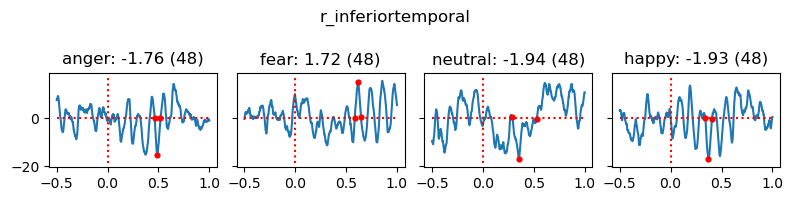

not normalizing
0.618790183357353


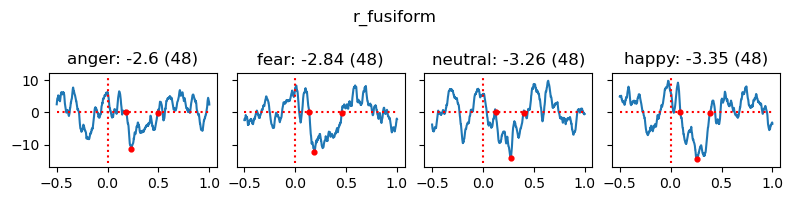

not normalizing
0.6225464524186223


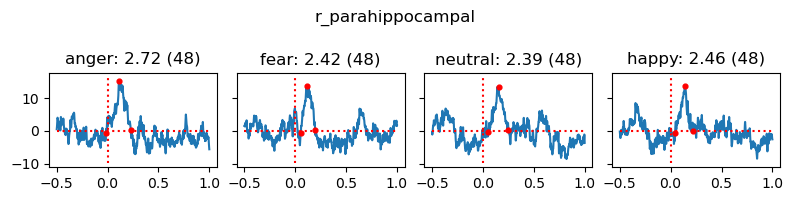

not normalizing
0.5772111545657639


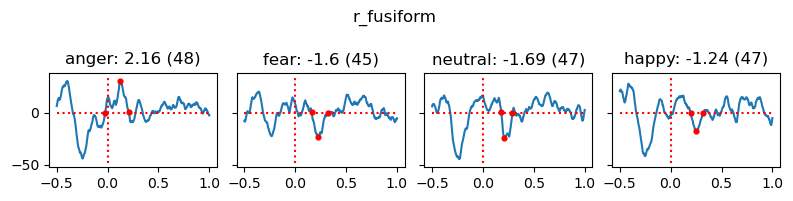

not normalizing
0.09678783705187499


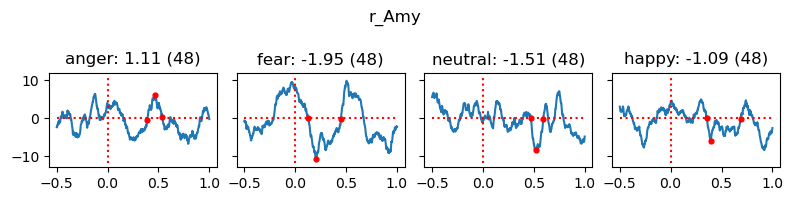

not normalizing
0.28168796421776865


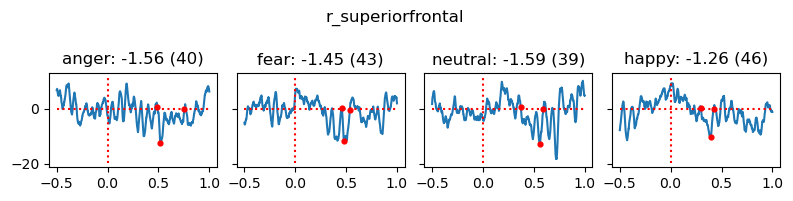

not normalizing
0.7438041113845065


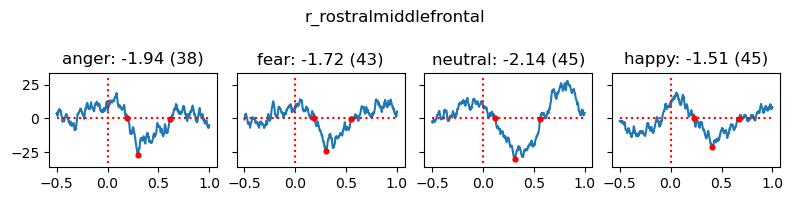

In [5]:
pairs_list = np.array(utils.find_valid_pairs(montage.loc[:,"name"].to_list()))

# parameters for signal processing
resrate = 1024
lpfreq = 300
# time prior to (pre) and after (post) image onset
pre = -0.5
post = 1
# parameters for noise estimation
win_dur = 0.125 # seconds
MAD_thresh = 8.0 # median absolute deviations
min_dur = 0.125 # seconds

img_cats = ["anger","fear","neutral","happy"]
# collect df for each pair for later concatenation
reg_list = []
for pair in pairs_list:
    reg = montage.region[montage.name==pair[0]].item()
    ts,bipolar,filtwins1 = filtering.bipolar_reref(data.loc[:,pair[::-1]],origfs,
                                                   resrate,lpfreq=lpfreq,norm=None)
    
    # this could be done outside of the loop for the first pair, set for all subsequent
    t_ixs = np.array([np.where((ts>=(im_t+pre))&(ts<=(im_t+post))) for im_t in img_ts]).squeeze()
    plot_ts = np.linspace(pre,post,t_ixs.shape[1])
    # image onset
    ix0 = min(np.where(plot_ts>=0)[0])
    # restrict to 50 ms after onset
    ixA = min(np.where(plot_ts>=0.05)[0])
    # restrict to 667 ms post onset
    ixB = min(np.where(plot_ts>=0.667)[0])
    
    # see how many trials have amplitude excursions within the ERP window
    norm_env = spike_utils.envelope_noise_screen(bipolar, resrate, window_s=win_dur)
    # 500 ms of baseline
    base_ixs = np.array(t_ixs[:,:int(resrate/2)]-resrate/2,dtype=int)
    # filter the trials with too many amplitude excursions in the pre/post window
    t_mask = np.sum(np.int64((norm_env>MAD_thresh)[t_ixs]),axis=1)<(min_dur*resrate)
    n_ts = events.loc[t_mask,:].groupby(by="img_category").block.count()
    # normalization factor for ERP max (stdev of ERP baseline)
    basestd = np.std(bipolar[base_ixs].mean(axis=1))
    
    # ERP calculations
    fig,ax = plt.subplots(1,len(img_cats),figsize=[8,2], tight_layout=True, sharey=True)
    reg_dfs = []
    avg_ERPs = np.zeros([resrate,len(img_cats)])
    for ix,cat in enumerate(img_cats):
        cat_dict = {}
        ERP_tfilt = bipolar[t_ixs[(events.img_category==cat)&(t_mask),:]].mean(axis=0)
        pre_1, max1, post_1 = template_extrema(ERP_tfilt,ixA=ixA,ixB=ixB)
        normamp = ERP_tfilt[max1]/basestd
        ax[ix].plot(plot_ts,ERP_tfilt)
        ax[ix].plot(plot_ts[[0,-1]],[0,0],"r:")
        ax[ix].scatter(plot_ts[[pre_1,max1,post_1]],ERP_tfilt[[pre_1,max1,post_1]],
                       s=12,color="r",zorder=2)
        ax[ix].set_title(f"{cat}: {round(normamp,2)} ({n_ts.to_dict()[cat]})")
        cat_dict["value"] = [normamp,plot_ts[max1],(post_1-pre_1)/resrate]
        cat_dict["variable"] = ["normamp","latency","event_dur"]
        reg_dfs.append(pd.DataFrame(cat_dict))
        reg_dfs[ix]["category"] = cat
        # collect the first second of data after image presentation
        # going to use it to make comparisons (how correlated are ERPs)
        avg_ERPs[:,ix] = ERP_tfilt[ix0:] 
        
    ERP_corrs = np.triu(np.corrcoef(avg_ERPs,rowvar=False),k=1)
    pair_corrs = ERP_corrs[np.nonzero(ERP_corrs)].mean()
    print(pair_corrs)
    
    ylims = ax[-1].get_ylim()    
    [ax[ix].plot([0,0],ylims,"r:") for ix in range(len(img_cats))] 
    
    reg_dfs.append(pd.DataFrame({"value":[pair_corrs],"variable":["avgcorr"],"category":["all"]}))
    reg_df = pd.concat(reg_dfs,ignore_index=True)
    reg_df["region"] = reg
    reg_df["contacts"] = pair[1]+"-"+pair[0]
    reg_list.append(reg_df)
    
    fig.suptitle(reg)
    plt.show()

    

ERP_df = pd.concat(reg_list,ignore_index=True)
ERP_df["ID"] = montage.ID.unique()[0]
ERP_df["age"] = montage.age.unique()[0].astype(np.float64)

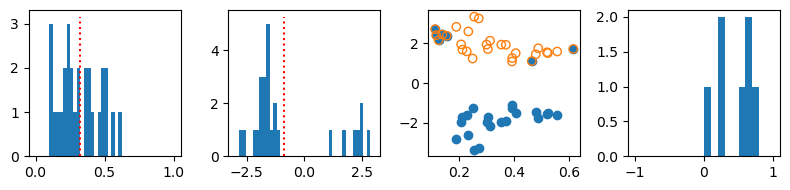

In [6]:
# plot summaries
fig,[ax1,ax2,ax3,ax4] = plt.subplots(1,4,figsize=[8,2], tight_layout=True)
lats = ERP_df.value[ERP_df.variable=="latency"]
amps = ERP_df.value[ERP_df.variable=="normamp"]
ax1.hist(lats, bins=np.linspace(0,1,41))
ax1.plot(np.ones(2)*lats.mean(),ax1.get_ylim(),"r:")
ax2.hist(amps, bins=np.linspace(-3,3,41))
ax2.plot(np.ones(2)*amps.mean(),ax2.get_ylim(),"r:")
ax3.scatter(lats,amps,color="C0")
ax3.scatter(lats,abs(amps),facecolor='none',edgecolors="C1")
ax4.hist(ERP_df.value[ERP_df.variable=="avgcorr"], bins=np.linspace(-1,1,21))
plt.show()

In [7]:
savestr = fstr+fr"\EmotionTask_{montage.ID.unique()[0]}_ERPdata.csv"
print(savestr)
ERP_df[["ID","age","region","contacts","value","variable","category"]].to_csv(savestr,index=False)

C:\Users\jmile3\OneDrive - SCH\emotional_faces_data\ea2142\EmotionTask\EmotionTask_ea2125_ERPdata.csv


In [8]:
# hm. do I want to add ERP stuff here? Or just use this for data checks?
# probably just data checks

def plot_ERPs(ERP_mat,imgs,ERP_thresh,plot_ts,ixA,ixB):
    '''
    plot average ERP for each image category
    specify categories (array of strings)
    set threshold for SNR calculation
    use ixA and ixB as integer ixs for finding max/min
    '''

    if "house" in imgs.to_numpy():
        ERP_mat = ERP_mat[imgs!="house",:]
        imgs = imgs[imgs!="house"]
        
    img_cats = imgs.unique()
    img_cats.sort()
    
    fig,ax = plt.subplots(2,len(img_cats),tight_layout=True,figsize=(12,6),
                         sharex=True)
    cmap = plt.cm.grey
    vmin = np.percentile(ERP_mat.flatten(),2.5)
    vmax = np.percentile(ERP_mat.flatten(),97.5)
    xticks = np.linspace(min(plot_ts),max(plot_ts),7)
    yticks = np.round(ax[0,0].get_yticks(),decimals=2)
    pline = np.ones((len(plot_ts),))

    # make a dict of amplitudes and array of avg ERPs
    ERP_amps = {}
    ERPs = np.zeros([len(img_cats),len(plot_ts)])
    # iterate through image categories and plot
    for ix,cat in enumerate(img_cats):
        catmat = ERP_mat[imgs==cat,:]
        ERP = np.nanmean(catmat,axis=0)
        ERPs[ix,:] = ERP
        max_ix = np.argmax(ERP[ixA:ixB])+ixA
        min_ix = np.argmin(ERP[ixA:ixB])+ixA
        
        ax[0,ix].plot(plot_ts,ERP)
        ax[0,ix].set_title(cat)
        ax[0,ix].scatter(plot_ts[max_ix],ERP[max_ix])
        ax[0,ix].scatter(plot_ts[min_ix],ERP[min_ix])
    
        ax[0,ix].fill_between(plot_ts, pline*(-ERP_thresh),
                           pline*(ERP_thresh),
                           color=[0.4,0.4,0.4,0.25]) 
        ax[1,ix].pcolormesh(plot_ts, range(catmat.shape[0]), catmat,
                            cmap=cmap, vmin=vmin, vmax=vmax, shading="nearest")
        
        ERP_amps[cat] = ERP[max_ix] - ERP[min_ix]
   
    # do some axis organization and plot editing   
    [ax[0,ix].set_xticks(xticks,labels=[]) for ix in range(ax.shape[1])]
    ampval = np.max(np.abs(ERPs.flatten()))*1.125
    [ax[0,ix].set_ylim([-ampval,ampval]) for ix in range(ax.shape[1])]
    [ax[0,ix].set_yticklabels([]) for ix in range(1,ax.shape[1])]
    [ax[0,ix].plot([0,0],ax[0,ix].get_ylim(),"r:") for ix in range(ax.shape[1])]
    [ax[1,ix].set_xticks(xticks,labels=[]) for ix in range(ax.shape[1])]
    [ax[1,ix].set_yticks(yticks,labels=[]) for ix in range(ax.shape[1])]
    [ax[1,ix].plot([0,0],ax[1,ix].get_ylim(),"r:") for ix in range(ax.shape[1])]
    
    return ERP_amps,ax